<a href="https://colab.research.google.com/github/Hansini07/ML_Project/blob/main/Agriculture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Dataset.zip to Dataset.zip


In [5]:
print(uploaded.keys())

dict_keys(['Dataset.zip'])


In [6]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

extract_path = "/content/crop_dataset"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [7]:
print(os.listdir("/content/crop_dataset"))

['state_soil_data.csv', 'state_weather_data_1997_2020.csv', 'crop_yield.csv']


In [8]:
import pandas as pd

crop = pd.read_csv(
    "/content/crop_dataset/crop_yield.csv"
)

soil = pd.read_csv(
    "/content/crop_dataset/state_soil_data.csv"
)

weather = pd.read_csv(
    "/content/crop_dataset/state_weather_data_1997_2020.csv"
)

print("All three datasets loaded successfully!")

All three datasets loaded successfully!


In [9]:
print("Crop dataset shape   :", crop.shape)
print("Soil dataset shape   :", soil.shape)
print("Weather dataset shape:", weather.shape)

Crop dataset shape   : (19689, 9)
Soil dataset shape   : (30, 5)
Weather dataset shape: (720, 5)


In [10]:
crop.head()

,crop,year,season,state,area,production,fertilizer,pesticide,yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909


In [11]:
soil.head()

,state,N,P,K,pH
0,Andhra Pradesh,78,45,22,6.8
1,Arunachal Pradesh,55,15,35,5.5
2,Assam,60,18,38,5.8
3,Bihar,85,30,25,7.2
4,Chhattisgarh,70,35,20,6.5


In [12]:
weather.head()

,state,year,avg_temp_c,total_rainfall_mm,avg_humidity_percent
0,Andhra Pradesh,1997,28.21,1191.08,69.56
1,Andhra Pradesh,1998,28.21,1100.41,71.95
2,Andhra Pradesh,1999,28.03,603.67,66.91
3,Andhra Pradesh,2000,27.74,1070.25,70.73
4,Andhra Pradesh,2001,28.08,910.13,68.69


In [16]:
print("CROP MISSING VALUES")
print(crop.isnull().sum())

print("SOIL MISSING VALUES")
print(soil.isnull().sum())

print("WEATHER MISSING VALUES")
print(weather.isnull().sum())

CROP MISSING VALUES
crop          0
year          0
season        0
state         0
area          0
production    0
fertilizer    0
pesticide     0
yield         0
dtype: int64
SOIL MISSING VALUES
state    0
N        0
P        0
K        0
pH       0
dtype: int64
WEATHER MISSING VALUES
state                   0
year                    0
avg_temp_c              0
total_rainfall_mm       0
avg_humidity_percent    0
dtype: int64


In [17]:
crop["state"] = crop["state"].str.strip()
soil["state"] = soil["state"].str.strip()
weather["state"] = weather["state"].str.strip()

In [18]:
crop["crop"] = crop["crop"].str.strip()
crop["season"] = crop["season"].str.strip()

In [19]:
weather = weather.rename(columns={
    "rainfall_mm": "total_rainfall_mm",
    "humidity_%": "avg_humidity_percent"
})

In [20]:
data = pd.merge(
    crop,
    soil,
    on="state",
    how="left"
)

print(data.shape)

(19689, 13)


In [21]:
data = pd.merge(
    data,
    weather,
    on=["state", "year"],
    how="left"
)

print("Final merged dataset shape:")
print(data.shape)

Final merged dataset shape:
(19689, 16)


In [22]:
data.head()

,crop,year,season,state,area,production,fertilizer,pesticide,yield,N,P,K,pH,avg_temp_c,total_rainfall_mm,avg_humidity_percent
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087,60,18,38,5.8,22.41,1468.92,70.71
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435,60,18,38,5.8,22.41,1468.92,70.71
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333,60,18,38,5.8,22.41,1468.92,70.71
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739,60,18,38,5.8,22.41,1468.92,70.71
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909,60,18,38,5.8,22.41,1468.92,70.71


In [23]:
data.shape

(19689, 16)

In [24]:
data.isnull().sum()

,0
crop,0
year,0
season,0
state,0
area,0
production,0
fertilizer,0
pesticide,0
yield,0
N,0


In [25]:
data.duplicated().sum()

np.int64(0)

DATASET OVERVIEW
Dataset shape: (19689, 16)
Number of rows: 19689
Number of columns: 16

Missing values:
0

Duplicate rows:
0

Unique crops   : 55
Unique seasons : 6
Unique states  : 30

YIELD STATISTICS
Mean   : 79.95
Median : 1.03
Std    : 878.31
Minimum: 0.0
Maximum: 21105.0


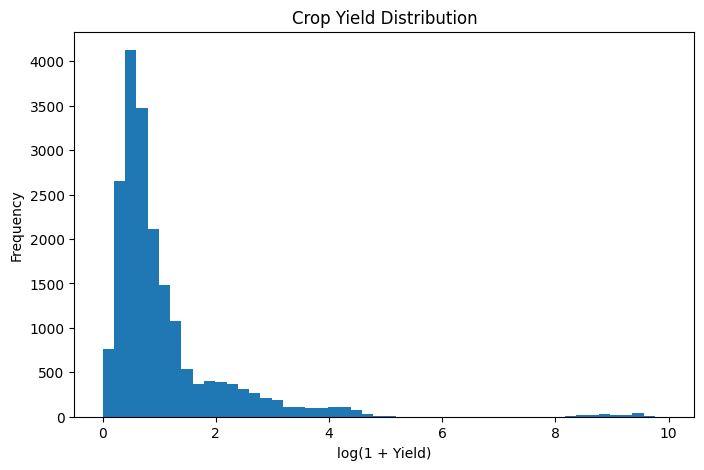

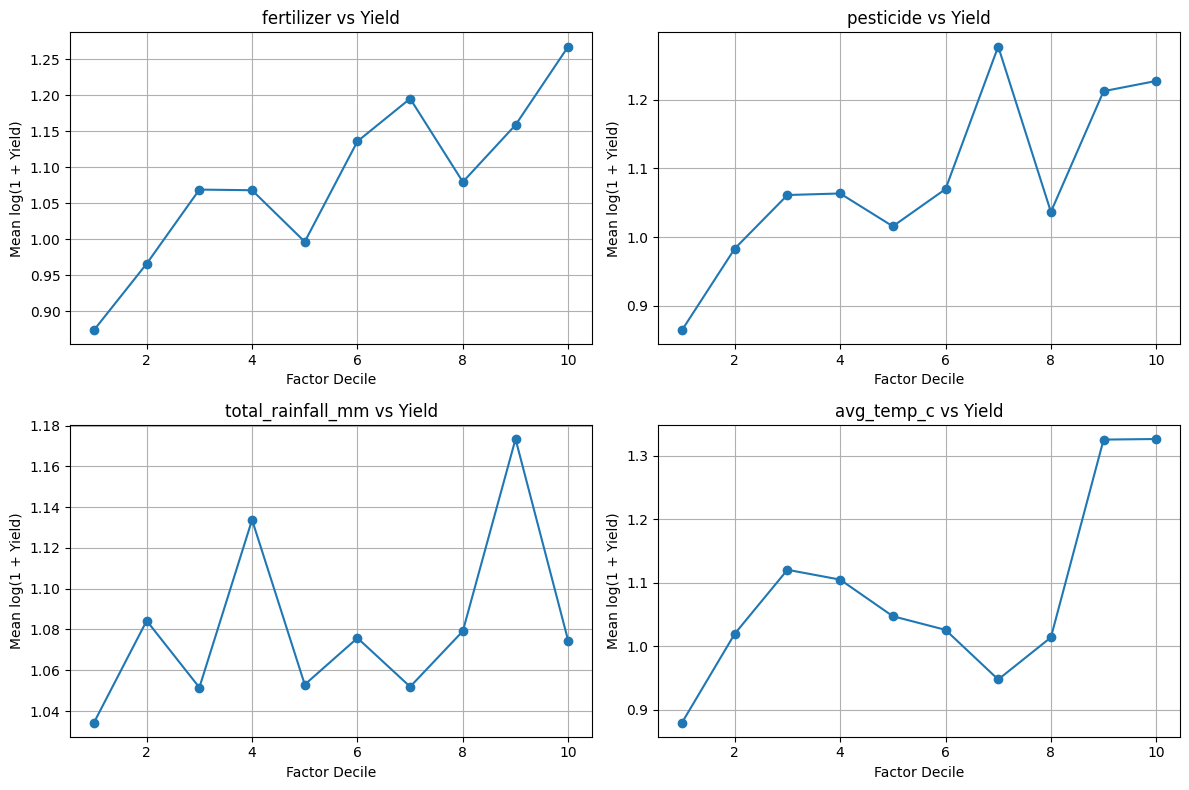

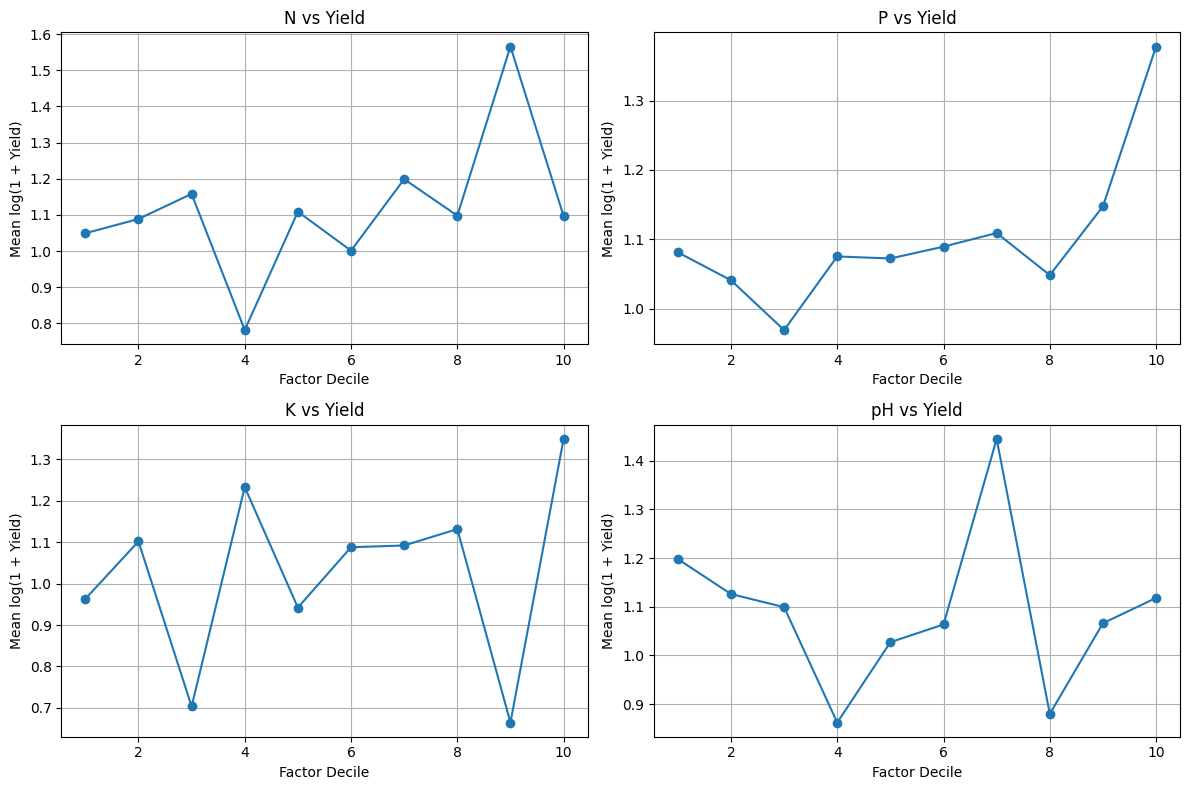


CORRELATION MATRIX


,area,production,fertilizer,pesticide,yield,N,P,K,pH,avg_temp_c,total_rainfall_mm,avg_humidity_percent
area,1.000000,0.037441,0.973255,0.973479,0.001858,0.124458,0.135969,-0.083703,0.164031,0.093623,-0.015394,-0.100639
production,0.037441,1.000000,0.039799,0.035171,0.570809,-0.011919,0.009488,0.038002,-0.028948,0.035431,0.005398,0.049706
fertilizer,0.973255,0.039799,1.000000,0.954991,0.002862,0.127427,0.140520,-0.090087,0.171053,0.096276,-0.008658,-0.100757
pesticide,0.973479,0.035171,0.954991,1.000000,0.001782,0.115843,0.127084,-0.077768,0.153144,0.087692,-0.014607,-0.095627
yield,0.001858,0.570809,0.002862,0.001782,1.000000,0.000567,0.040731,0.043650,-0.021938,0.048464,0.005191,0.063663
N,0.124458,-0.011919,0.127427,0.115843,0.000567,1.000000,0.681839,0.081185,0.746875,0.290200,-0.321874,-0.523429
P,0.135969,0.009488,0.140520,0.127084,0.040731,0.681839,1.000000,-0.297064,0.777696,0.565385,-0.383468,-0.312062
K,-0.083703,0.038002,-0.090087,-0.077768,0.043650,0.081185,-0.297064,1.000000,-0.385525,-0.298719,0.202958,0.229333
pH,0.164031,-0.028948,0.171053,0.153144,-0.021938,0.746875,0.777696,-0.385525,1.000000,0.374044,-0.475040,-0.709155
avg_temp_c,0.093623,0.035431,0.096276,0.087692,0.048464,0.290200,0.565385,-0.298719,0.374044,1.000000,-0.034133,-0.002167


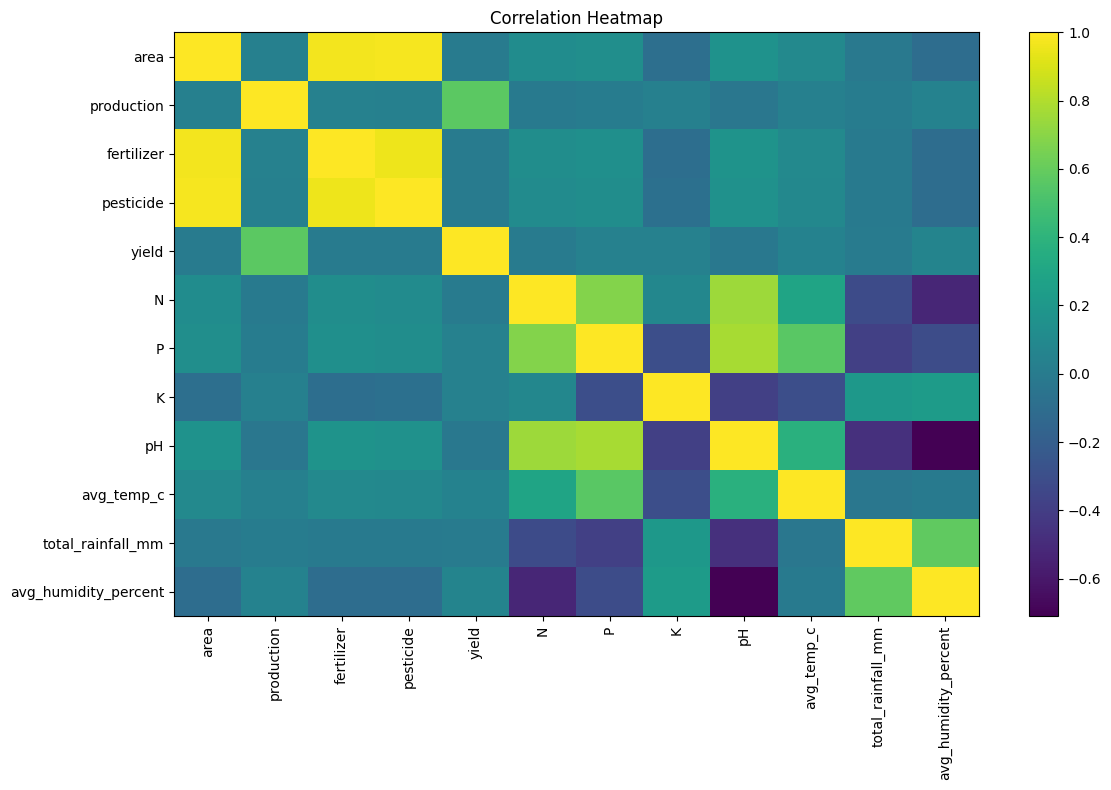


IMPORTANT CORRELATIONS
Area - Fertilizer: 0.97
Area - Pesticide: 0.97
Fertilizer - Pesticide: 0.95


In [26]:
# ============================================================
# PART 2 - EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. BASIC INFORMATION
# ------------------------------------------------------------

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("Dataset shape:", data.shape)
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nMissing values:")
print(data.isnull().sum().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

print("\nUnique crops   :", data["crop"].nunique())
print("Unique seasons :", data["season"].nunique())
print("Unique states  :", data["state"].nunique())


# ------------------------------------------------------------
# 2. YIELD STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("YIELD STATISTICS")
print("=" * 70)

print("Mean   :", round(data["yield"].mean(), 2))
print("Median :", round(data["yield"].median(), 2))
print("Std    :", round(data["yield"].std(), 2))
print("Minimum:", round(data["yield"].min(), 2))
print("Maximum:", round(data["yield"].max(), 2))


# ------------------------------------------------------------
# 3. YIELD DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(data["yield"]),
    bins=50
)

plt.xlabel("log(1 + Yield)")
plt.ylabel("Frequency")
plt.title("Crop Yield Distribution")

plt.show()


# ------------------------------------------------------------
# 4. AGRICULTURAL FACTORS VS YIELD
# ------------------------------------------------------------

factors = [
    "fertilizer",
    "pesticide",
    "total_rainfall_mm",
    "avg_temp_c"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8)
)

for ax, factor in zip(axes.flatten(), factors):

    temp = data[[factor, "yield"]].copy()

    temp["log_yield"] = np.log1p(
        temp["yield"]
    )

    temp["decile"] = pd.qcut(
        temp[factor],
        10,
        duplicates="drop"
    )

    grouped = temp.groupby(
        "decile",
        observed=True
    )["log_yield"].mean()

    ax.plot(
        range(1, len(grouped) + 1),
        grouped.values,
        marker="o"
    )

    ax.set_title(
        f"{factor} vs Yield"
    )

    ax.set_xlabel("Factor Decile")
    ax.set_ylabel("Mean log(1 + Yield)")
    ax.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. SOIL FACTORS VS YIELD
# ------------------------------------------------------------

soil_factors = ["N", "P", "K", "pH"]

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8)
)

for ax, factor in zip(
    axes.flatten(),
    soil_factors
):

    temp = data[[factor, "yield"]].copy()

    temp["log_yield"] = np.log1p(
        temp["yield"]
    )

    temp["decile"] = pd.qcut(
        temp[factor],
        10,
        duplicates="drop"
    )

    grouped = temp.groupby(
        "decile",
        observed=True
    )["log_yield"].mean()

    ax.plot(
        range(1, len(grouped) + 1),
        grouped.values,
        marker="o"
    )

    ax.set_title(
        f"{factor} vs Yield"
    )

    ax.set_xlabel("Factor Decile")
    ax.set_ylabel("Mean log(1 + Yield)")
    ax.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. CORRELATION
# ------------------------------------------------------------

numeric_columns = [
    "area",
    "production",
    "fertilizer",
    "pesticide",
    "yield",
    "N",
    "P",
    "K",
    "pH",
    "avg_temp_c",
    "total_rainfall_mm",
    "avg_humidity_percent"
]

correlation = data[numeric_columns].corr()

print("\n" + "=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)

display(correlation)


# ------------------------------------------------------------
# 7. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. IMPORTANT CORRELATIONS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMPORTANT CORRELATIONS")
print("=" * 70)

print(
    "Area - Fertilizer:",
    round(correlation.loc["area", "fertilizer"], 2)
)

print(
    "Area - Pesticide:",
    round(correlation.loc["area", "pesticide"], 2)
)

print(
    "Fertilizer - Pesticide:",
    round(correlation.loc["fertilizer", "pesticide"], 2)
)

In [27]:
# ============================================================
# PART 3 - PREPARE DATA FOR MACHINE LEARNING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------

numeric_features = [
    "area",
    "fertilizer",
    "pesticide",
    "N",
    "P",
    "K",
    "pH",
    "avg_temp_c",
    "total_rainfall_mm",
    "avg_humidity_percent"
]

categorical_features = [
    "crop",
    "season",
    "state"
]

# Target
X = data[
    numeric_features + categorical_features
]

y = data["yield"]


# ------------------------------------------------------------
# CHRONOLOGICAL TRAIN / TEST SPLIT
# ------------------------------------------------------------

train_mask = data["year"] <= 2015
test_mask = data["year"] >= 2016

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]


print("=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("Training years: 1997 - 2015")
print("Testing years : 2016 - 2020")

print("\nTraining records:", len(X_train))
print("Testing records :", len(X_test))


# ------------------------------------------------------------
# PREPROCESSING
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("\nPreprocessing ready!")
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

TRAIN / TEST SPLIT
Training years: 1997 - 2015
Testing years : 2016 - 2020

Training records: 15404
Testing records : 4285

Preprocessing ready!
Numerical features: 10
Categorical features: 3


In [28]:
# ==========================================
# PART 4 — RIDGE REGRESSION
# ==========================================

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Ridge pipeline
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

# Values of alpha to test
alpha_values = np.logspace(-3, 3, 50)

# 5-Fold Cross Validation
ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid={"model__alpha": alpha_values},
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train Ridge model
ridge_search.fit(X_train, y_train)

# Prediction on test data
ridge_pred = ridge_search.predict(X_test)

# Evaluation
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

# Results
print("========== RIDGE REGRESSION ==========")
print("Best Alpha:", ridge_search.best_params_["model__alpha"])
print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

========== RIDGE REGRESSION ==========
Best Alpha: 3.5564803062231287
MAE : 56.23892329150203
MSE : 91958.98325200885
RMSE: 303.2473961174421
R²  : 0.8731418577602325


In [ ]:
# ==========================================
# PART 5 — LASSO REGRESSION
# ==========================================

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Lasso pipeline
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=20000))
])

# Alpha values to test
alpha_values = np.logspace(-3, 3, 50)

# 5-Fold Cross Validation
lasso_search = GridSearchCV(
    lasso_pipeline,
    param_grid={"model__alpha": alpha_values},
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train Lasso model
lasso_search.fit(X_train, y_train)

# Prediction on test data
lasso_pred = lasso_search.predict(X_test)

# Evaluation
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

# Results
print("========== LASSO REGRESSION ==========")
print("Best Alpha:", lasso_search.best_params_["model__alpha"])
print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE:", lasso_rmse)
print("R²  :", lasso_r2)

In [ ]:
# ==========================================
# PART 6 — ELASTIC NET REGRESSION
# ==========================================

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Elastic Net pipeline
elastic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ElasticNet(max_iter=20000))
])

# Alpha and L1 ratio values
alpha_values = np.logspace(-3, 3, 50)

# 5-Fold Cross Validation
elastic_search = GridSearchCV(
    elastic_pipeline,
    param_grid={
        "model__alpha": alpha_values,
        "model__l1_ratio": [0.5]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train Elastic Net model
elastic_search.fit(X_train, y_train)

# Prediction on test data
elastic_pred = elastic_search.predict(X_test)

# Evaluation
elastic_mae = mean_absolute_error(y_test, elastic_pred)
elastic_mse = mean_squared_error(y_test, elastic_pred)
elastic_rmse = np.sqrt(elastic_mse)
elastic_r2 = r2_score(y_test, elastic_pred)

# Results
print("========== ELASTIC NET REGRESSION ==========")
print("Best Alpha:", elastic_search.best_params_["model__alpha"])
print("L1 Ratio:", elastic_search.best_params_["model__l1_ratio"])
print("MAE :", elastic_mae)
print("MSE :", elastic_mse)
print("RMSE:", elastic_rmse)
print("R²  :", elastic_r2)